In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/amz_uk_price_prediction_dataset.csv")

# Part 1: Understanding Product Categories

In [3]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [4]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [8]:
category_counts = df['category'].value_counts()

# With the head(5) code we can see the top 5 categories
category_counts.head(5)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

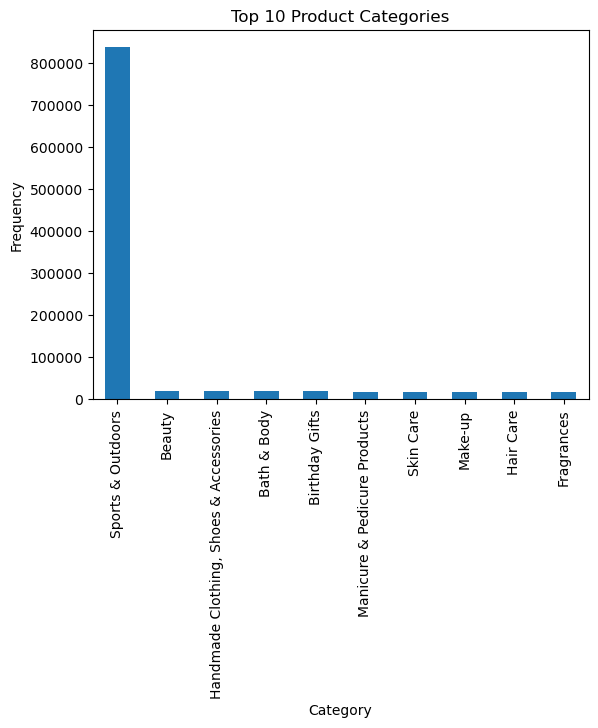

In [14]:
subset = category_counts.head(10)

plt.figure()
subset.plot(kind='bar')

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Frequency")

plt.show()

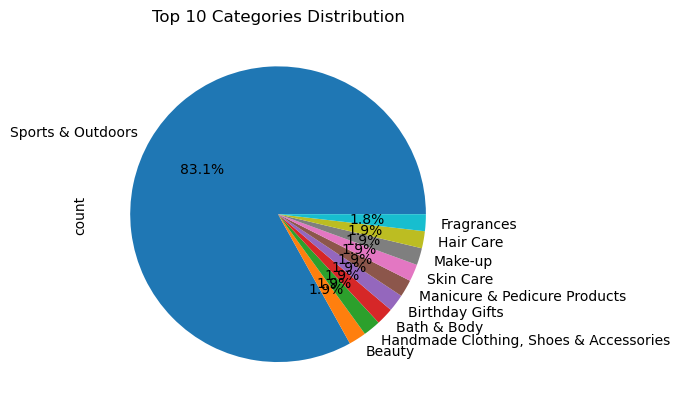

In [16]:
plt.figure()
subset.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top 10 Categories Distribution")

plt.show()

The pie chart shows that "Sports & Outdoors" dominates the dataset, accounting for more than 80% of the listings.


# Part 2: Delving into Product Pricing

In [17]:
df['price'].head()

0    21.99
1    23.99
2    21.99
3    31.99
4    17.99
Name: price, dtype: float64

In [18]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)

Mean: 89.24380943923661
Median: 19.09
Mode: 9.99


The mean price of products is 89.24, while the median price is 19.09, and the mode is 9.99.

The fact that the mean is significantly higher than the median indicates a right-skewed distribution, meaning that a small number of very expensive products are pulling the average upward.

In [19]:
variance = df['price'].var()
std_dev = df['price'].std()
price_range = df['price'].max() - df['price'].min()
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)

print("Variance:", variance)
print("Std Dev:", std_dev)
print("Range:", price_range)
print("IQR:", iqr)

Variance: 119445.48532256528
Std Dev: 345.60886175352226
Range: 100000.0
IQR: 36.0


The variance and standard deviation are quite high, indicating a large spread in product prices.

The price range is extremely wide, which further confirms the presence of significant variability and extreme values in the dataset.

Overall, these metrics indicate that while most products are priced within a moderate range, there are extreme outliers that greatly increase the overall dispersion.

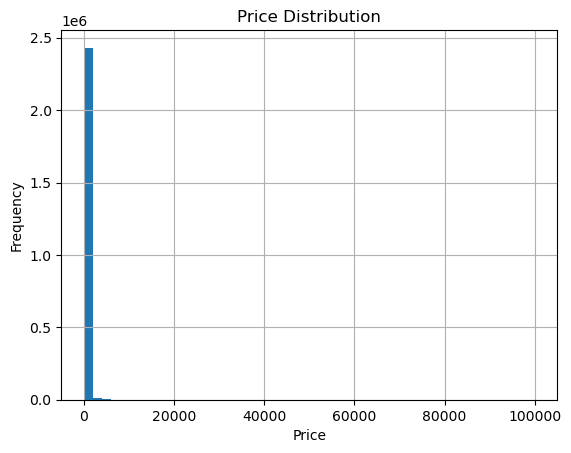

In [20]:
plt.figure()
df['price'].hist(bins=50)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

The histogram shows that the majority of products are concentrated in the lower price range, with a high frequency of low-cost items.

The chart is difficult to interpret because of the presence of extremely high-priced outliers, which compress the distribution and make most values appear clustered near zero.

This issue can be resolved by removing or limiting outliers (for example, using the 95th percentile) or by applying a log transformation to better visualize the distribution.

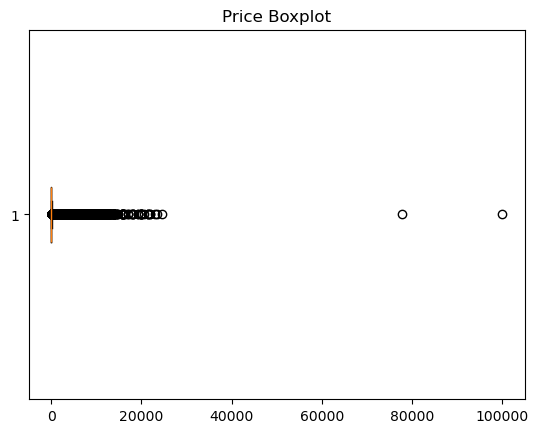

In [21]:
plt.figure()
plt.boxplot(df['price'], vert=False)

plt.title("Price Boxplot")

plt.show()

The boxplot clearly shows the presence of numerous outliers, especially on the higher end of the price spectrum.

# Part 3: Unpacking Product Ratings

In [36]:
df['stars'].head()

0    4.7
1    4.7
2    4.7
3    4.7
4    4.6
Name: stars, dtype: float64

In [37]:
ratings = df['stars'].dropna()

In [38]:
mean_rating = ratings.mean()
median_rating = ratings.median()
mode_rating = ratings.mode()[0]

print("Mean:", mean_rating)
print("Median:", median_rating)
print("Mode:", mode_rating)

Mean: 2.152836472966066
Median: 0.0
Mode: 0.0


The mean rating is approximately 2.15, while the median and mode are both 0.0.

This indicates that a large number of products have a rating of 0, which significantly lowers both the median and the most frequent value.

In [39]:
variance_rating = ratings.var()
std_rating = ratings.std()
iqr_rating = ratings.quantile(0.75) - ratings.quantile(0.25)

print("Variance:", variance_rating)
print("Std Dev:", std_rating)
print("IQR:", iqr_rating)

Variance: 4.81743402976196
Std Dev: 2.1948653785054697
IQR: 4.4


Overall, these metrics indicate that ratings are not consistent and show significant variability, largely due to the presence of both zero and high ratings.

In [40]:
skewness_rating = ratings.skew()
kurtosis_rating = ratings.kurt()

print("Skewness:", skewness_rating)
print("Kurtosis:", kurtosis_rating)

Skewness: 0.08120735761080881
Kurtosis: -1.9260061280432994


The distribution is not perfectly normal and is influenced by the large number of zero ratings combined with clusters of high ratings.

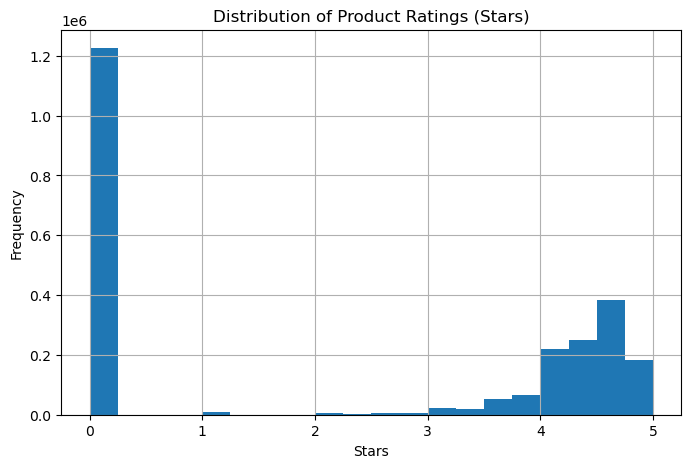

In [41]:
plt.figure(figsize=(8,5))
ratings.hist(bins=20)

plt.title("Distribution of Product Ratings (Stars)")
plt.xlabel("Stars")
plt.ylabel("Frequency")

plt.show()

The most common rating is 0, which reflects the large number of unrated products rather than actual customer dissatisfaction.